Saving dessert_sales_dataset.csv to dessert_sales_dataset (1).csv
Model:
Sales = 147.73827517226107 + 9.343631918203995 * Month + 15.128250722382674 * Festival - -33.88464103134028 * Exam + 19.697488330740264 * Weather + 36.34229828850857 * Holiday


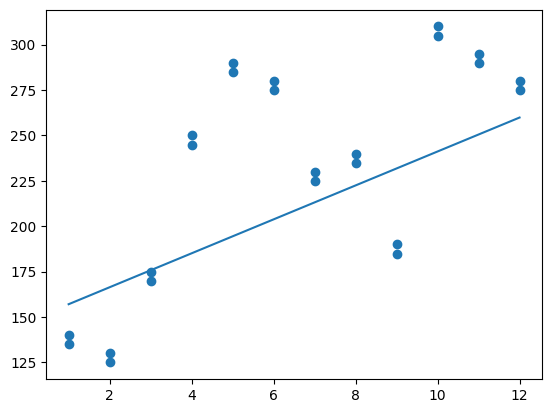


Eigenvalues: [1.31872646e+03 1.80477336e+01 8.99538334e-01 3.63514473e+00
 6.69112013e+00]

Eigenvectors:
 [[ 0.99285087 -0.05099838  0.10106651 -0.03650924 -0.00994761]
 [ 0.08131461  0.36112703 -0.32216515  0.85735565 -0.15532581]
 [ 0.02130105 -0.05857538 -0.42849688 -0.29280968 -0.85250695]
 [-0.00862383  0.85881859  0.41352046 -0.23904859 -0.18496718]
 [ 0.08430292  0.35494505 -0.72896257 -0.34745738  0.46345871]]

Most influential direction (Eigenvector):
[ 0.99285087  0.08131461  0.02130105 -0.00862383  0.08430292]

Singular Values: [36.31427355  4.24826242  2.58671996  1.90660555  0.94843995]

Predicted Sales (SVD Approx): [ 12.34802422  23.07454949  76.48532667 103.29401475 115.64203896
 114.99022097  71.21242367  83.72112518  81.44780825 149.31924928
 161.6672735  174.01529772  12.34802422  23.07454949  76.48532667
 103.29401475 115.64203896 114.99022097  71.21242367  83.72112518
  81.44780825 149.31924928 161.6672735  174.01529772]

Month with Highest Sales (SVD): 12


In [2]:
from google.colab import files
uploaded = files.upload()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("dessert_sales_dataset.csv")

# Extract variables
t = data["Month"].values
sales = data["Sales"].values
festival = data["Festival"].values
exam = data["Exam"].values
weather = data["Weather"].values
holiday = data["Holiday"].values

# Matrix A
A = np.column_stack((np.ones(len(t)), t, festival, exam, weather, holiday))

# Least squares
x = np.linalg.inv(A.T @ A) @ A.T @ sales

C, D, F, E, W, H = x

print("Model:")
print("Sales =", C, "+", D, "* Month +", F, "* Festival -", E, "* Exam +", W, "* Weather +", H, "* Holiday")

# Plot
plt.scatter(t, sales)
t_line = np.linspace(1, 12, 100)
plt.plot(t_line, C + D*t_line)
plt.show()

# --- EIGENVALUE ANALYSIS ---

# Remove constant column for analysis
A_features = np.column_stack((t, festival, exam, weather, holiday))

# Covariance matrix
C = A_features.T @ A_features

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(C)

print("\nEigenvalues:", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

# Find most important factor
max_index = np.argmax(eigenvalues)
print("\nMost influential direction (Eigenvector):")
print(eigenvectors[:, max_index])

# --- SVD ANALYSIS ---

# Use feature matrix (excluding constant)
A_features = np.column_stack((t, festival, exam, weather, holiday))

# Apply SVD
U, S, VT = np.linalg.svd(A_features)

print("\nSingular Values:", S)

# Reconstruct using top k components (k=2 for simplicity)
k = 2
S_k = np.zeros((k, k))
np.fill_diagonal(S_k, S[:k])

A_reconstructed = U[:, :k] @ S_k @ VT[:k, :]

# Use reconstructed matrix to estimate sales trend
approx_sales = A_reconstructed @ np.array([D, F, -E, W, H])

# Find month with highest predicted sales
max_index = np.argmax(approx_sales)
best_month = t[max_index]

print("\nPredicted Sales (SVD Approx):", approx_sales)
print("\nMonth with Highest Sales (SVD):", best_month)